In [1]:
import os
import pandas as pd
import re
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
import seaborn as sns
import librosa
from pathlib import Path

Загрузка данных и преобразование в удобный формат

In [ ]:
file_path = './darpa-timit-acousticphonetic-continuous-speech/versions/6/SPKRINFO.TXT'

In [3]:
def parse_sprkinfo(file_path):
    """Парсит файл SPKRINFO.TXT TIMIT"""
    
    data = []
    in_data_section = False
    line_num = 0
    
    with open(file_path, 'r') as f:
        for line in f:
            line_num += 1
            line = line.rstrip()
            
            # Ищем начало таблицы
            if ';ID  Sex DR Use' in line:
                in_data_section = True
                continue
            
            # Пропускаем комментарии
            if line.startswith(';'):
                continue
            
            # Пропускаем разделители
            if line.startswith('--') or not line.strip():
                continue
            
            # Парсим строки данных
            if in_data_section:
                
                parts = re.split(r'\s{2,}', line.strip())
                
                if len(parts) >= 9:
                    # Убираем лишние пробелы в каждом поле
                    row = [p.strip() for p in parts[:9]]
                    
                    # Если есть комментарий (10+ поле)
                    if len(parts) > 9:
                        comment = ' '.join(parts[9:]).strip()
                        row.append(comment)
                    else:
                        row.append('')
                    
                    data.append(row)
                else:
                    print(f"Строка {line_num}: неполная - {parts}")
    
    return data

# Загрузка
data = parse_sprkinfo(file_path)

columns = ['ID', 'Sex', 'DR', 'Use', 'RecDate', 'BirthDate', 'Ht', 'Race', 'Edu', 'Comments']
df = pd.DataFrame(data, columns=columns)

In [7]:
df = df[~df['BirthDate'].str.contains('\?\?', na=False)]

df['BirthDate_dt'] = pd.to_datetime(df['BirthDate'], format='%m/%d/%y')
df['RecDate_dt'] = pd.to_datetime(df['RecDate'], format='%m/%d/%y')

# Корректируем двухзначные годы в BirthDate_dt
# Если дата рождения позже даты записи, вычитаем 100 лет
mask_wrong_century = df['BirthDate_dt'] > df['RecDate_dt']
df.loc[mask_wrong_century, 'BirthDate_dt'] = df.loc[mask_wrong_century, 'BirthDate_dt'] - pd.DateOffset(years=100)
df.loc[~mask_wrong_century, 'BirthDate_dt'] = df.loc[~mask_wrong_century, 'BirthDate_dt']

# Создаем колонку с вычисленным возрастом (используем исправленную дату рождения)
df['Age'] = (df['RecDate_dt'] - df['BirthDate_dt']).dt.days / 365.25

/tmp/ipykernel_4190209/364587119.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['BirthDate_dt'] = pd.to_datetime(df['BirthDate'], format='%m/%d/%y')
/tmp/ipykernel_4190209/364587119.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['RecDate_dt'] = pd.to_datetime(df['RecDate'], format='%m/%d/%y')
/tmp/ipykernel_4190209/364587119.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the cavea

In [ ]:
print(f"Загружено {len(df)} записей о дикторах")

speaker_to_age = dict(zip(df['ID'], df['Age']))
print(f"Создан словарь для {len(speaker_to_age)} дикторов")

predictions_file = "timit_age_predictions.txt"
ground_truth_file = "timit_ground_truth.csv"

def extract_speaker_id(file_path):
    """
    Извлекает ID диктора из пути к файлу TIMIT
    Пример: data/TEST/DR1/FAKS0/SA1.WAV -> FAKS0
    """
    parts = file_path.split('/')
    if len(parts) >= 4:
        speaker_dir = parts[3]
        return speaker_dir[1:]
    return None

ground_truth_data = []

with open(predictions_file, 'r') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
            
        parts = line.split()
        if len(parts) >= 2:
            file_path = parts[0]
            predicted_age = float(parts[1])
            
            speaker_id = extract_speaker_id(file_path)
            
            if speaker_id and speaker_id in speaker_to_age:
                true_age = speaker_to_age[speaker_id]
                
                ground_truth_data.append({
                    'file_path': file_path,
                    'speaker_id': speaker_id,
                    'true_age': true_age,
                    'predicted_age': predicted_age
                })
            else:
                print(f"Диктор {speaker_id} не найден в таблице для файла {file_path}")

df_ground_truth = pd.DataFrame(ground_truth_data)
df_ground_truth.to_csv(ground_truth_file, index=False)

print(f"\nСоздан файл с истинными метками: {ground_truth_file}")
print(f"Обработано {len(df_ground_truth)} записей")

if len(df_ground_truth) > 0:
    print("\n=== Статистика ===")
    print(f"Уникальных дикторов: {df_ground_truth['speaker_id'].nunique()}")
    print(f"Средний истинный возраст: {df_ground_truth['true_age'].mean():.2f} лет")
    print(f"Мин возраст: {df_ground_truth['true_age'].min():.2f} лет")
    print(f"Макс возраст: {df_ground_truth['true_age'].max():.2f} лет")
    
    # Показать первые несколько строк
    print("\nПервые 5 записей:")
    print(df_ground_truth.head().to_string())

Загружено 629 записей о дикторах
Создан словарь для 629 дикторов
Диктор KFB0 не найден в таблице для файла data/TRAIN/DR1/FKFB0/SA1.WAV
Диктор KFB0 не найден в таблице для файла data/TRAIN/DR1/FKFB0/SA2.WAV
Диктор KFB0 не найден в таблице для файла data/TRAIN/DR1/FKFB0/SI1608.WAV
Диктор KFB0 не найден в таблице для файла data/TRAIN/DR1/FKFB0/SI2238.WAV
Диктор KFB0 не найден в таблице для файла data/TRAIN/DR1/FKFB0/SI978.WAV
Диктор KFB0 не найден в таблице для файла data/TRAIN/DR1/FKFB0/SX168.WAV
Диктор KFB0 не найден в таблице для файла data/TRAIN/DR1/FKFB0/SX258.WAV
Диктор KFB0 не найден в таблице для файла data/TRAIN/DR1/FKFB0/SX348.WAV
Диктор KFB0 не найден в таблице для файла data/TRAIN/DR1/FKFB0/SX438.WAV
Диктор KFB0 не найден в таблице для файла data/TRAIN/DR1/FKFB0/SX78.WAV

Создан файл с истинными метками: timit_ground_truth.csv
Обработано 6290 записей

=== Статистика ===
Уникальных дикторов: 629
Средний истинный возраст: 30.37 лет
Мин возраст: 20.63 лет
Макс возраст: 75.77 лет

In [ ]:
df_preds = pd.read_csv('./timit_ground_truth.csv')

In [11]:
df_preds.head(1680)

,file_path,speaker_id,true_age,predicted_age
0,data/TEST/DR1/FAKS0/SA1.WAV,AKS0,28.320329,24.42
1,data/TEST/DR1/FAKS0/SA2.WAV,AKS0,28.320329,25.49
2,data/TEST/DR1/FAKS0/SI1573.WAV,AKS0,28.320329,22.29
3,data/TEST/DR1/FAKS0/SI2203.WAV,AKS0,28.320329,26.10
4,data/TEST/DR1/FAKS0/SI943.WAV,AKS0,28.320329,18.58
...,...,...,...,...
1675,data/TEST/DR8/MSLB0/SX113.WAV,SLB0,30.907598,14.66
1676,data/TEST/DR8/MSLB0/SX203.WAV,SLB0,30.907598,21.85
1677,data/TEST/DR8/MSLB0/SX23.WAV,SLB0,30.907598,19.40
1678,data/TEST/DR8/MSLB0/SX293.WAV,SLB0,30.907598,31.00


Обрезаем для оценки тестовую часть

In [12]:
df_preds=df_preds.head(1680)

In [13]:
df_preds.shape

(1680, 4)

In [15]:
df_preds['error'] = df_preds['predicted_age'] - df_preds['true_age']  
df_preds['abs_error'] = abs(df_preds['error'])                  
df_preds['squared_error'] = df_preds['error'] ** 2              

# Метрики
MAE = abs(df_preds['predicted_age'] - df_preds['true_age']).mean()
MSE = ((df_preds['predicted_age'] - df_preds['true_age'])**2).mean()
RMSE = np.sqrt(MSE)
STD_ERROR = (df_preds['predicted_age'] - df_preds['true_age']).std()

# Дополнительные метрики в пределах
within_10_years = (df_preds['abs_error'] <= 10).mean() * 100
within_5_years = (df_preds['abs_error'] <= 5).mean() * 100
within_3_years = (df_preds['abs_error'] <= 3).mean() * 100
within_1_year = (df_preds['abs_error'] <= 1).mean() * 100

print("Метрики оценки")

print(f"\nОсновные метрики:")
print(f"MAE  (Mean Absolute Error):     {MAE:.3f} лет")
print(f"RMSE (Root Mean Squared Error): {RMSE:.3f} лет")
print(f"Std of Error (разброс ошибок):  {STD_ERROR:.3f} лет")

print(f"\nПроцент ошибок в пределах:")
print(f"  ≤ 1 год:   {within_1_year:.1f}%")
print(f"  ≤ 3 года:  {within_3_years:.1f}%")
print(f"  ≤ 5 лет:   {within_5_years:.1f}%")
print(f"  ≤ 10 лет:   {within_10_years:.1f}%")

print(f"\nСтатистика абсолютных ошибок:")
print(f"  Мин ошибка:  {df_preds['abs_error'].min():.3f} лет")
print(f"  Медиана:     {df_preds['abs_error'].median():.3f} лет")
print(f"  Макс ошибка: {df_preds['abs_error'].max():.3f} лет")

#df.to_csv('evaluation_results_with_errors.csv', index=False)
#print(f"\nРезультаты с ошибками сохранены в 'evaluation_results_with_errors.csv'")

Метрики оценки

Основные метрики:
MAE  (Mean Absolute Error):     6.487 лет
RMSE (Root Mean Squared Error): 8.536 лет
Std of Error (разброс ошибок):  8.526 лет

Процент ошибок в пределах:
  ≤ 1 год:   9.8%
  ≤ 3 года:  29.6%
  ≤ 5 лет:   48.4%
  ≤ 10 лет:   80.1%

Статистика абсолютных ошибок:
  Мин ошибка:  0.001 лет
  Медиана:     5.161 лет
  Макс ошибка: 35.686 лет


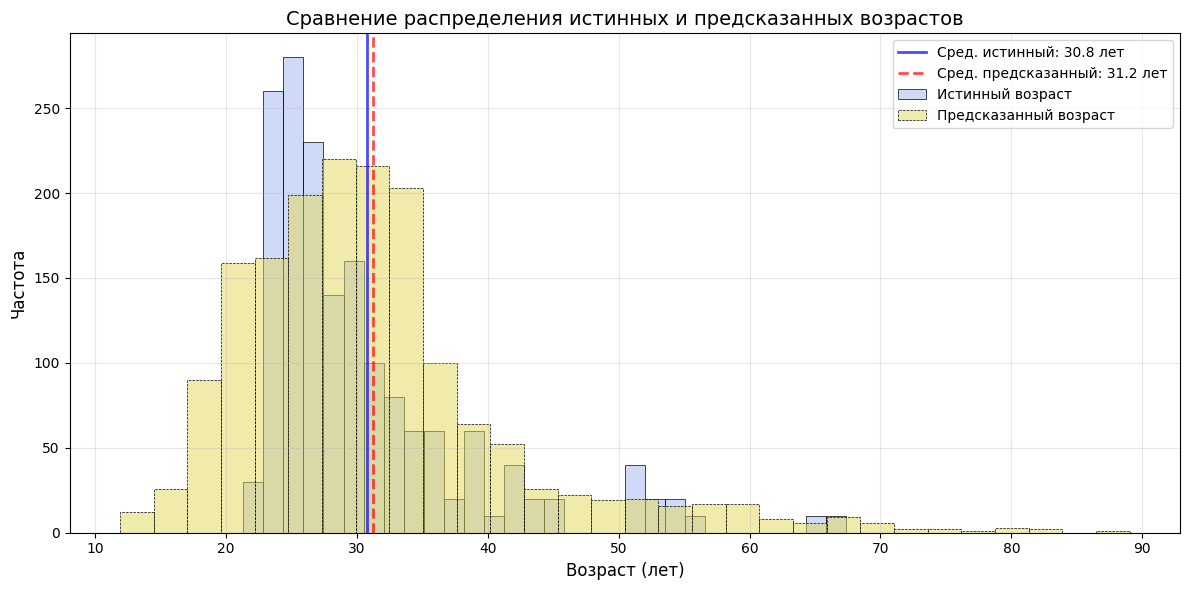

In [ ]:
plt.figure(figsize=(12, 6))

sns.histplot(data=df_preds, x='true_age', bins=30, 
             color='#A1B7F4', alpha=0.5, label='Истинный возраст',
             edgecolor='black', linewidth=0.5)
sns.histplot(data=df_preds, x='predicted_age', bins=30, 
             color="#E3D958", alpha=0.5, label='Предсказанный возраст',
             edgecolor='black', linewidth=0.5, linestyle='--')

plt.axvline(df_preds['true_age'].mean(), color='blue', linestyle='-', linewidth=2, alpha=0.7,
           label=f'Сред. истинный: {df_preds["true_age"].mean():.1f} лет')
plt.axvline(df_preds['predicted_age'].mean(), color='red', linestyle='--', linewidth=2, alpha=0.7,
           label=f'Сред. предсказанный: {df_preds["predicted_age"].mean():.1f} лет')

plt.xlabel('Возраст (лет)', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.title('Сравнение распределения истинных и предсказанных возрастов', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()